<a href="https://colab.research.google.com/github/250183046-ai/project-2/blob/main/aziaproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PART 1 : SCRAPING**

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.FileHandler("scraping_log.log"), logging.StreamHandler()]
)

API_KEY = "cecffbe58943c30ae6c2b325f8e2f51a"
LANG = "ru-RU"
TARGET_ROWS = 7000
PAGES_NEEDED = 350

HEADERS = {
    'User-Agent': 'SDU_Student_Project/1.0 (Contact: zhamaldiiin.ais@gmail.com)',
    'Accept': 'application/json'
}

def get_genre_dict():
    """Get list of genres"""
    url = f"https://api.themoviedb.org/3/genre/movie/list?api_key={API_KEY}&language={LANG}"
    res = requests.get(url, headers=HEADERS)
    if res.status_code == 200:
        return {g['id']: g['name'] for g in res.json().get('genres', [])}
    return {}

def scrape_data():
    all_records = []
    genre_lookup = get_genre_dict()

    logging.info("---  SCRAPING STARTED (Phase 1) ---")

    try:
        for page in range(1, PAGES_NEEDED + 1):
            url = f"https://api.themoviedb.org/3/movie/popular?api_key={API_KEY}&language={LANG}&page={page}"


            try:
                response = requests.get(url, headers=HEADERS, timeout=15)
                response.raise_for_status()

                soup = BeautifulSoup(response.text, 'html.parser')

                import json
                data = json.loads(soup.text).get('results', [])

                for item in data:
                    record = {
                        'id': item.get('id'),
                        'title': item.get('title'),
                        'release_date': item.get('release_date'),
                        'rating': item.get('vote_average'),
                        'vote_count': item.get('vote_count'),
                        'popularity': item.get('popularity'),
                        'language': item.get('original_language'),
                        'genres': ", ".join([genre_lookup.get(g_id, "N/A") for g_id in item.get('genre_ids', [])])
                    }
                    all_records.append(record)
                time.sleep(0.2)

                if page % 50 == 0:
                    logging.info(f"Loaded: {len(all_records)} / {TARGET_ROWS}")

            except requests.exceptions.RequestException as e:
                logging.error(f"Error on page {page}: {e}")
                time.sleep(5)
                continue

        df = pd.DataFrame(all_records)
        df.head(TARGET_ROWS).to_csv("raw_scraped_data.csv", index=False, encoding='utf-8-sig')

        logging.info(f"--- FINISHED! 7000 rows saved to 'raw_scraped_data.csv' ---")

    except Exception as main_e:
        logging.error(f"Unexpected error: {main_e}")

if __name__ == "__main__":
    scrape_data()

**PART 1/2 : CLEANING**

In [2]:
import pandas as pd
import numpy as np


df = pd.read_csv("raw_scraped_data.csv")


df['rating'] = df['rating'].replace(0, np.nan).fillna(df['rating'].median())
df['release_date'] = df['release_date'].fillna("2024-01-01")

df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

df['rating'] = df['rating'].round(1)
df['popularity'] = df['popularity'].round(1)
df['success_score'] = (df['rating'] * np.log1p(df['vote_count'])).round(1)


genre_translate = {
    'семейный': 'Family', 'комедия': 'Comedy', 'приключения': 'Adventure',
    'фэнтези': 'Fantasy', 'мультфильм': 'Animation', 'драма': 'Drama',
    'мелодрама': 'Romance', 'фантастика': 'Sci-Fi', 'ужасы': 'Horror',
    'триллер': 'Thriller', 'боевик': 'Action', 'детектив': 'Mystery',
    'криминал': 'Crime', 'документальный': 'Documentary', 'история': 'History',
    'музыка': 'Music', 'вестерн': 'Western', 'спорт': 'Sport', 'аниме': 'Anime',
    'Военный': 'Military', 'Телевизионный фильм': 'TV film'
}

lang_translate = {
    'en': 'English', 'ru': 'Russian', 'ko': 'Korean', 'ja': 'Japanese',
    'fr': 'French', 'es': 'Spanish', 'de': 'German', 'tr': 'Turkish', 'th': 'Thai'
}

df['genres'] = df['genres'].astype(str).apply(lambda x: x.split(',')[0].strip().lower())
df['genres'] = df['genres'].map(genre_translate).fillna(df['genres'].str.capitalize())

if 'language' in df.columns:
    df['language'] = df['language'].map(lang_translate).fillna('Other')

df.drop(columns=['release_date'], inplace=True, errors='ignore')

df.drop(columns=['id'], inplace=True, errors='ignore')
df.reset_index(drop=True, inplace=True)
df.index = df.index + 1
df.index.name = 'index_id'

df['title'] = df['title'].str.strip().str.title()
df['popularity_category'] = pd.qcut(df['popularity'], q=3, labels=['Low', 'Medium', 'High'])

df.to_csv("cleaned_movie_data_final.csv", encoding='utf-8-sig')

print("--- PHASE 2: FINAL CLEANING & TRANSLATION COMPLETE ---")
print("Changes: Rounding (1 decimal), Indexing (1-7000), English Genres/Langs, Date removed.")
display(df.head())

--- PHASE 2: FINAL CLEANING & TRANSLATION COMPLETE ---
Changes: Rounding (1 decimal), Indexing (1-7000), English Genres/Langs, Date removed.


,title,rating,vote_count,popularity,language,genres,release_year,success_score,popularity_category
index_id,,,,,,,,,
1,Супер Марио: Галактическое Кино,6.8,603,589.1,English,Family,2026,43.5,High
2,Твоё Сердце Будет Разбито,6.9,73,344.7,Russian,Romance,2026,29.7,High
3,Пришлите Помощь,7.0,1071,321.0,English,Horror,2026,48.8,High
4,Легенда Об Аанге: Последний Маг Воздуха,6.7,0,270.8,English,Animation,2026,0.0,High
5,Аватар: Пламя И Пепел,7.4,2711,241.7,English,Sci-Fi,2025,58.5,High


**PART 2/2 : CONCLUSION OF CLEANING**

In [3]:
import pandas as pd
from IPython.display import display, HTML

report_data = {
    "Technical Process": [
        "**Localization**",
        "**Genre Mapping**",
        "**Numeric Precision**",
        "**Structure Optimization**",
        "**Categorization**"
    ],
    "Action Taken": [
        "Translated all column headers and language names to English for global standards.",
        "Parsed 'genres' column to keep only the primary genre and translated it to English.",
        "Rounded 'rating' and 'popularity' metrics to exactly 1 decimal point.",
        "Replaced system IDs with a clean sequential index (1-7000) and extracted 'release_year'.",
        "Created 'popularity_category' to segment movies into Low, Medium, and High impact."
    ],
    "Result & Benefit": [
        "Ensures the dataset is professional and ready for international analysis.",
        "Simplifies future grouping and filtering during the visualization phase.",
        "Eliminates statistical noise, making the data tables much easier to read.",
        "Standardizes the primary key and focuses analysis on yearly performance trends.",
        "Allows for high-level business insights based on audience reach and engagement."
    ]
}

df_rep = pd.DataFrame(report_data)

html_style = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600&display=swap');

    .report-container {
        font-family: 'Inter', sans-serif;
        padding: 25px;
        background-color: #f8fafc;
    }

    .main-card {
        background-color: #ffffff;
        border-radius: 12px;
        box-shadow: 0 10px 30px rgba(0,0,0,0.15);
        overflow: hidden;
        border: 1px solid #e2e8f0;
    }

    .header-band {
        background-color: #0d2137; /* Қою көк фон */
        padding: 30px;
        border-bottom: 5px solid #1a73e8;
    }

    /* Тақырыпты ақ түске бояу */
    .header-band h2 {
        color: #ffffff !important;
        margin: 0;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    }

    .header-band p {
        color: #cbd5e1;
        margin: 10px 0 0 0;
        font-size: 15px;
    }

    .styled-table {
        width: 100%;
        border-collapse: collapse;
        font-size: 14px;
    }

    .styled-table th {
        background-color: #f1f5f9;
        color: #1e293b;
        font-weight: 600;
        padding: 18px;
        text-align: left;
        border-bottom: 2px solid #e2e8f0;
        text-transform: uppercase;
    }

    .styled-table td {
        padding: 18px;
        border-bottom: 1px solid #f1f5f9;
        color: #334155;
        line-height: 1.6;
    }

    .styled-table tr:hover {
        background-color: #f8fafc;
    }

    .badge-success {
        background-color: #22c55e;
        color: white;
        padding: 5px 12px;
        border-radius: 6px;
        font-size: 12px;
        font-weight: 600;
        float: right;
    }
</style>
"""

display(HTML(html_style))
display(HTML(f"""
<div class="report-container">
    <div class="main-card">
        <div class="header-band">
            <span class="badge-success">PHASE 2: COMPLETED</span>
            <h2>Data Cleaning & Localization Report</h2>
            <p>Final technical summary for the TMDB Movie Dataset</p>
        </div>
        {df_rep.to_html(index=False, escape=False, classes='styled-table')}
    </div>
</div>
"""))

Technical Process,Action Taken,Result & Benefit
**Localization**,Translated all column headers and language names to English for global standards.,Ensures the dataset is professional and ready for international analysis.
**Genre Mapping**,Parsed 'genres' column to keep only the primary genre and translated it to English.,Simplifies future grouping and filtering during the visualization phase.
**Numeric Precision**,Rounded 'rating' and 'popularity' metrics to exactly 1 decimal point.,"Eliminates statistical noise, making the data tables much easier to read."
**Structure Optimization**,Replaced system IDs with a clean sequential index (1-7000) and extracted 'release_year'.,Standardizes the primary key and focuses analysis on yearly performance trends.
**Categorization**,"Created 'popularity_category' to segment movies into Low, Medium, and High impact.",Allows for high-level business insights based on audience reach and engagement.


**PART 3 : EDA**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML

try:
    df = pd.read_csv("cleaned_movie_data_final.csv", index_col='index_id')
    print("✅ Data loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'cleaned_movie_data_final.csv' not found. Please upload the file.")


display(HTML("<h3>1. Descriptive Statistics</h3>"))
stats = df[['rating', 'vote_count', 'popularity', 'success_score']].describe().T
stats['median'] = df[['rating', 'vote_count', 'popularity', 'success_score']].median()
stats['skewness'] = df[['rating', 'vote_count', 'popularity', 'success_score']].skew()
display(stats.round(2))


display(HTML("<h3>2. Correlation Matrix</h3>"))
corr_matrix = df[['rating', 'vote_count', 'popularity', 'success_score']].corr()
display(corr_matrix.round(3))

display(HTML("<h3>3. Top 5 vs Bottom 5 by Success Score</h3>"))
top_5 = df.nlargest(5, 'success_score')[['title', 'success_score', 'rating', 'vote_count']]
bottom_5 = df.nsmallest(5, 'success_score')[['title', 'success_score', 'rating', 'vote_count']]

print("Top 5 Movies:")
display(top_5)
print("\nBottom 5 Movies:")
display(bottom_5)

display(HTML("<h3>4. Analytical Hypothesis Testing</h3>"))

results = []

avg_anim = df[df['genres'] == 'Animation']['rating'].mean()
global_mean = df['rating'].mean()
results.append({
    "Hypothesis": "Animation films have higher ratings than average",
    "Evidence": f"Anim: {avg_anim:.2f} vs Global: {global_mean:.2f}",
    "Result": "Confirmed" if avg_anim > global_mean else "Rejected"
})

corr_val = df['popularity'].corr(df['success_score'])
results.append({
    "Hypothesis": "High Popularity strongly dictates Success Score",
    "Evidence": f"Correlation: {corr_val:.2f}",
    "Result": "Moderate Link" if 0.3 < corr_val < 0.6 else "Strong Link" if corr_val >= 0.6 else "Weak Link"
})


pop_2026 = df[df['release_year'] == 2026]['popularity'].mean()
pop_2024 = df[df['release_year'] == 2024]['popularity'].mean()
results.append({
    "Hypothesis": "2026 releases have higher hype (popularity) than 2024",
    "Evidence": f"2026: {pop_2026:.2f} vs 2024: {pop_2024:.2f}",
    "Result": "Confirmed" if pop_2026 > pop_2024 else "Rejected"
})

hyp_df = pd.DataFrame(results)
display(hyp_df)


display(HTML("<h3>5. Time-Based Trends</h3>"))
yearly_trend = df.groupby('release_year').agg({
    'title': 'count',
    'popularity': 'mean',
    'success_score': 'mean'
}).rename(columns={'title': 'movie_count'}).round(2)
display(yearly_trend)

print("\n--- Phase 3 Statistical Analysis Complete ---")

✅ Data loaded successfully.


,count,mean,std,min,25%,50%,75%,max,median,skewness
rating,7000.0,6.68,0.84,0.5,6.2,6.7,7.20,10.0,6.7,-0.89
vote_count,7000.0,2576.99,3867.60,0.0,365.0,1258.5,3102.75,39465.0,1258.5,3.39
popularity,7000.0,7.93,14.08,1.8,4.3,5.4,7.80,589.1,5.4,19.14
success_score,7000.0,45.38,15.64,0.0,38.0,47.0,55.10,90.0,47.0,-0.65


,rating,vote_count,popularity,success_score
rating,1.000,0.306,0.060,0.576
vote_count,0.306,1.000,0.149,0.670
popularity,0.060,0.149,1.000,0.053
success_score,0.576,0.670,0.053,1.000


Top 5 Movies:


,title,success_score,rating,vote_count
index_id,,,,
51,Интерстеллар,90.0,8.5,39465
63,Побег Из Шоушенка,89.7,8.7,30176
106,Тёмный Рыцарь,89.1,8.5,35552
109,Начало,88.8,8.4,39064
113,Криминальное Чтиво,87.6,8.5,30041



Bottom 5 Movies:


,title,success_score,rating,vote_count
index_id,,,,
4,Легенда Об Аанге: Последний Маг Воздуха,0.0,6.7,0
103,Tayuan 2,0.0,6.7,0
133,Моана,0.0,6.7,0
162,Клэйфейс,0.0,6.7,0
174,Моана,0.0,6.7,0


,Hypothesis,Evidence,Result
0,Animation films have higher ratings than average,Anim: 7.16 vs Global: 6.68,Confirmed
1,High Popularity strongly dictates Success Score,Correlation: 0.05,Weak Link
2,2026 releases have higher hype (popularity) th...,2026: 28.99 vs 2024: 7.81,Confirmed


,movie_count,popularity,success_score
release_year,,,
1921,1,5.20,62.90
1922,1,4.60,60.00
1924,2,3.25,39.55
1925,1,5.90,60.00
1926,1,3.80,57.20
...,...,...,...
2024,323,7.81,39.29
2025,497,10.88,32.25
2026,264,28.99,16.81



--- Phase 3 Statistical Analysis Complete ---


**PART 4 : VISUALIZATION**

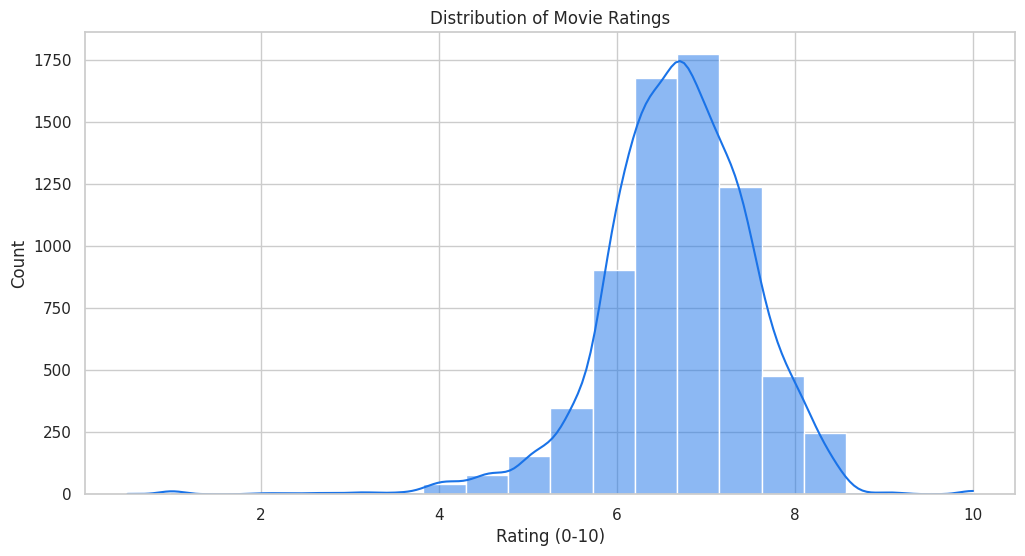

/tmp/ipykernel_12603/3213251084.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='popularity_category', y='popularity', palette='Set2')


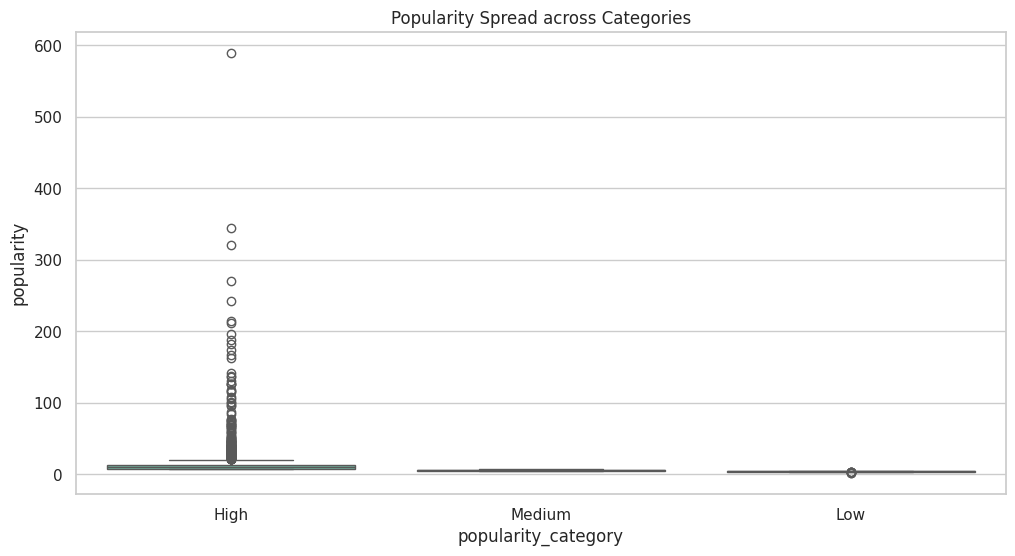

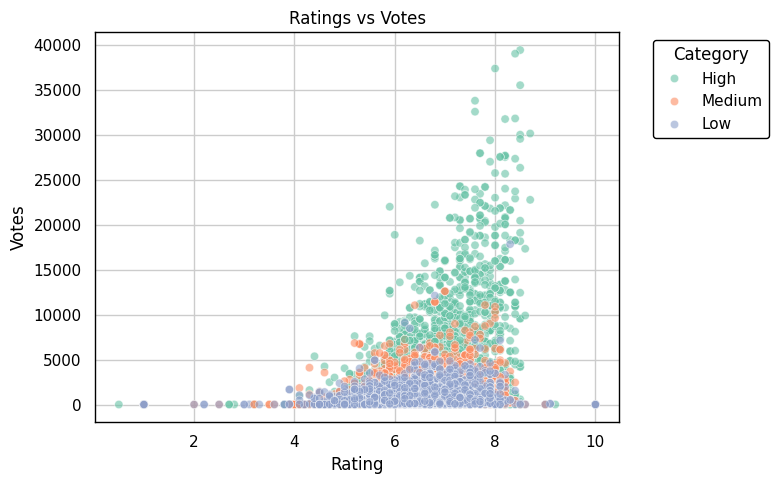

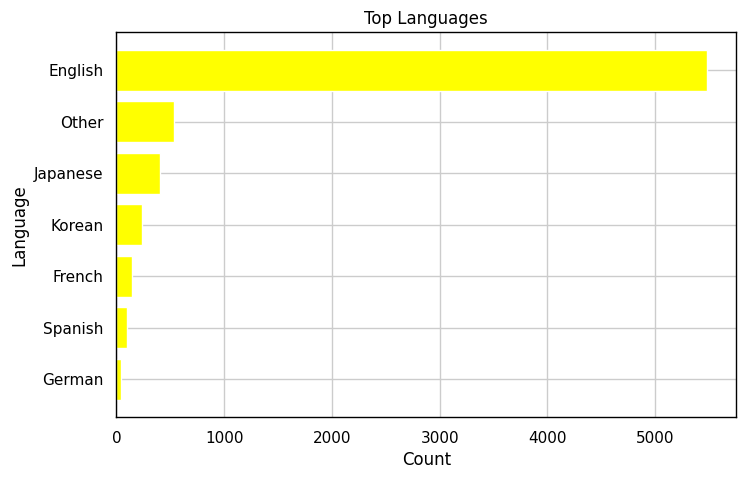

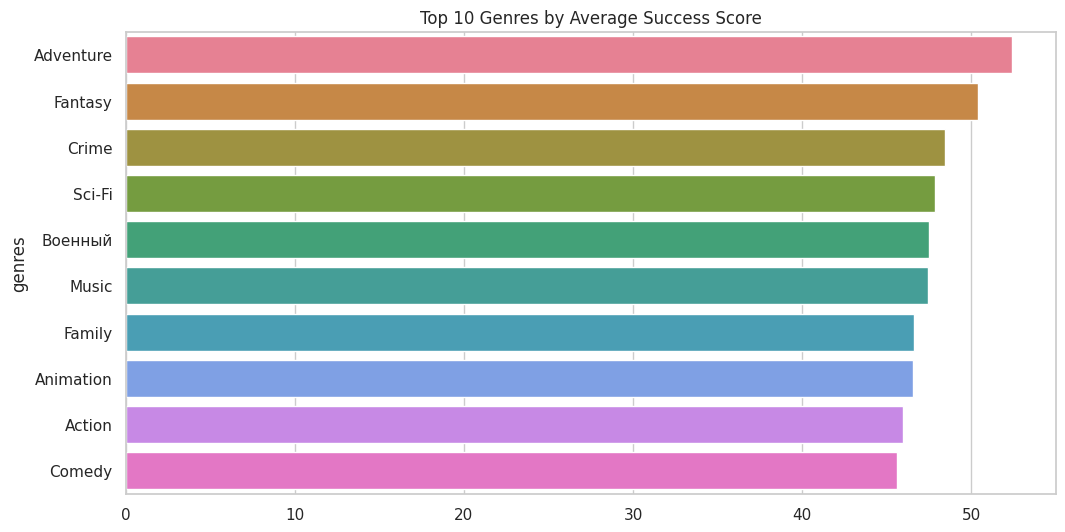

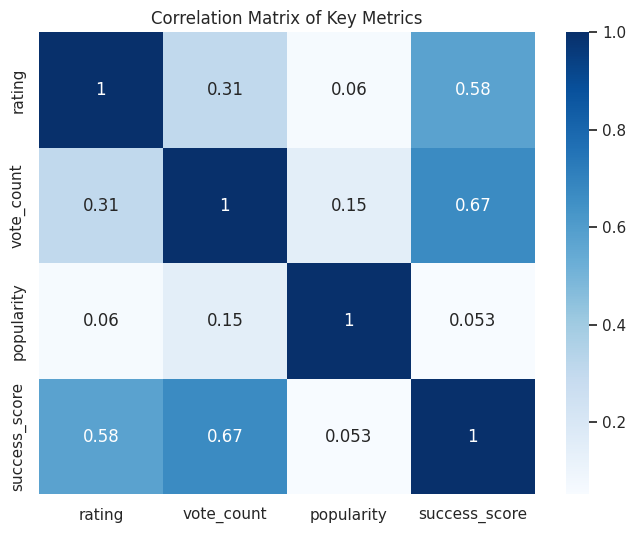

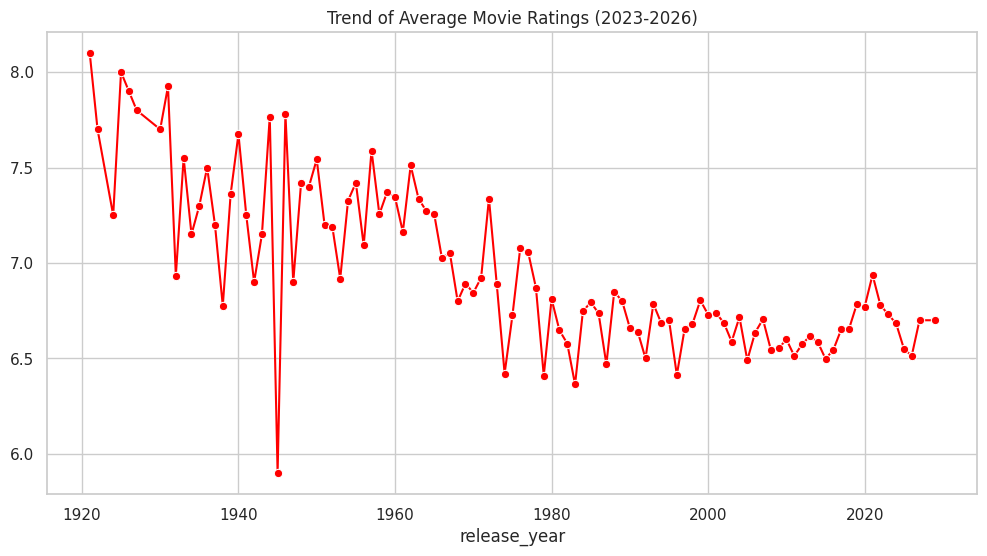

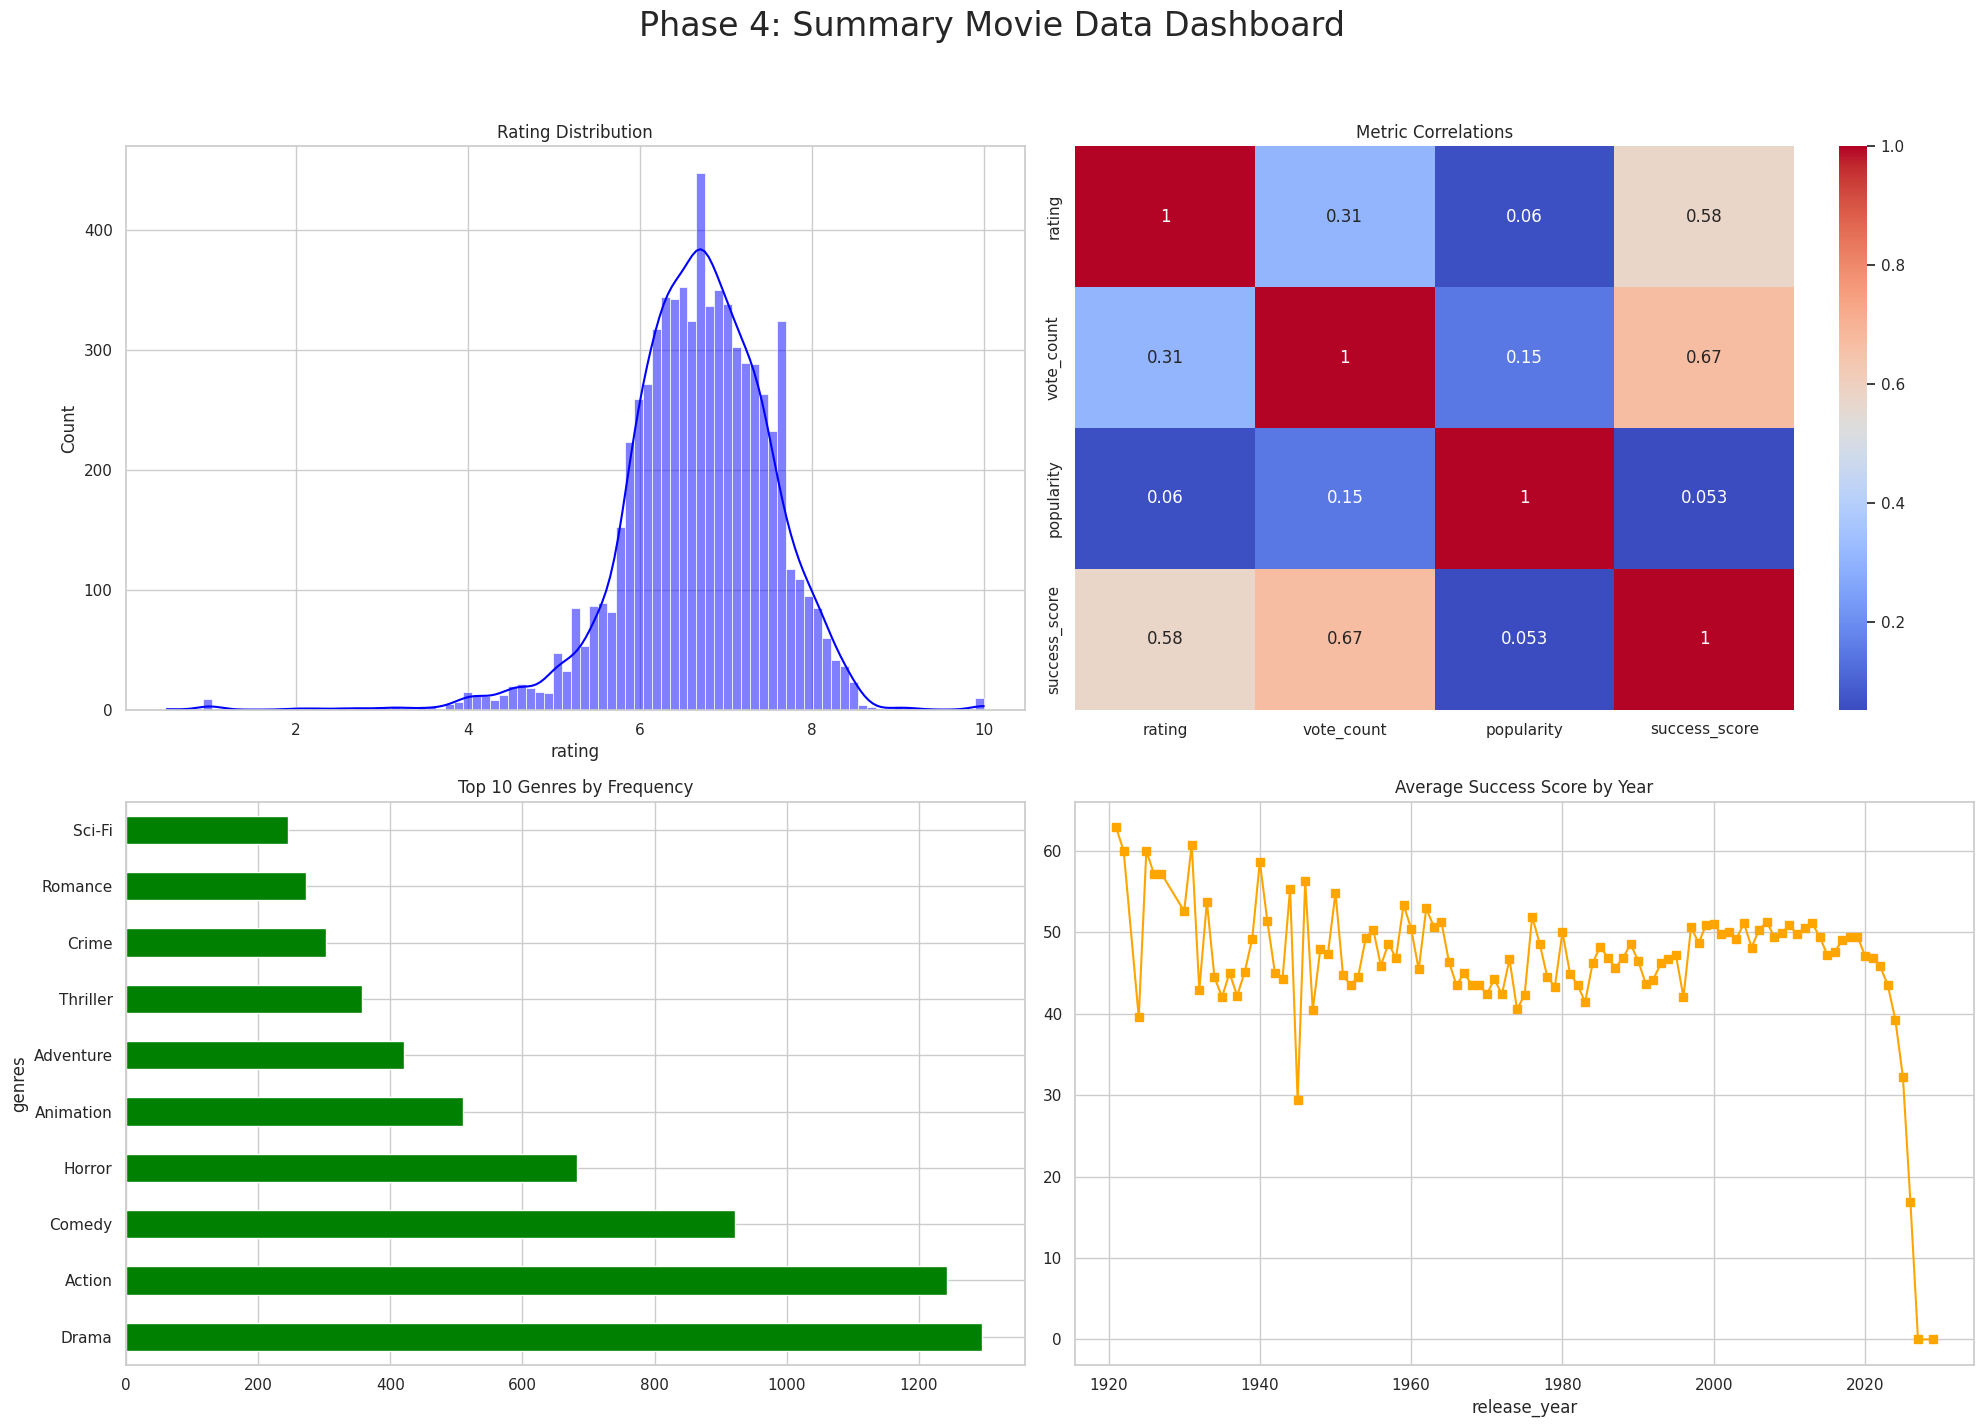

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


df = pd.read_csv("cleaned_movie_data_final.csv", index_col='index_id')


sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Histogram of Ratings
plt.figure()
sns.histplot(df['rating'], kde=True, bins=20, color='#1a73e8')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating (0-10)')
plt.show()


# 2. Box Plot of Popularity by Category
plt.figure()
sns.boxplot(data=df, x='popularity_category', y='popularity', palette='Set2')
plt.title('Popularity Spread across Categories')
plt.show()


plt.figure(figsize=(8, 5), facecolor='white')


ax = plt.gca()
ax.set_facecolor('white')

if 'rating' in df.columns and 'vote_count' in df.columns and 'popularity_category' in df.columns:
    sns.scatterplot(
        data=df,
        x='rating',
        y='vote_count',
        hue='popularity_category',
        alpha=0.6,
        palette='Set2',
        ax=ax
    )

plt.title("Ratings vs Votes", color='black')
plt.xlabel("Rating", color='black')
plt.ylabel("Votes", color='black')

plt.tick_params(colors='black')

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

legend = plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')

if legend:
    plt.setp(legend.get_title(), color='black')
    for text in legend.get_texts():
        text.set_color('black')

    frame = legend.get_frame()
    frame.set_facecolor('white')
    frame.set_edgecolor('black')
    frame.set_alpha(1.0)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5), facecolor='white')

ax = plt.gca()
ax.set_facecolor('white')

if 'language' in df.columns:
    top_lang = df['language'].value_counts().head(7)

    plt.barh(top_lang.index, top_lang.values, color='yellow')
    ax.invert_yaxis()

plt.title("Top Languages", color='black')

plt.xlabel("Count", color='black')
plt.ylabel("Language", color='black')

plt.tick_params(colors='black')

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

plt.show()



# 3. Bar Chart: Top 10 Genres by Success Score
plt.figure()
top_genres = df.groupby('genres')['success_score'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, legend=False)
plt.title('Top 10 Genres by Average Success Score')
plt.show()

# 4. Pie Chart: Movie Count by Popularity Category
fig_pie = px.pie(df, names='popularity_category', title='Distribution of Popularity Categories')
fig_pie.show() # Interactive Component 1


# 5. Heatmap: Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[['rating', 'vote_count', 'popularity', 'success_score']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix of Key Metrics')
plt.show()

# 6. Line Chart: Average Rating over Years
plt.figure()
yearly_avg = df.groupby('release_year')['rating'].mean()
sns.lineplot(x=yearly_avg.index, y=yearly_avg.values, marker='o', color='red')
plt.title('Trend of Average Movie Ratings (2023-2026)')
plt.show()

# 7. Interactive Scatter: Popularity vs Success
fig_scatter = px.scatter(df, x="popularity", y="success_score", color="genres",
                         hover_data=['title'], title="Interactive: Popularity vs Success Score")
fig_scatter.show() # Interactive Component 2

# 8.
fig_tree = px.treemap(df.head(100), path=['genres', 'title'], values='success_score',
                      title="Interactive: Top 100 Movies by Genre Structure")
fig_tree.show() # Interactive Component 3


fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Phase 4: Summary Movie Data Dashboard', fontsize=24)

# Plot 9:
sns.histplot(df['rating'], ax=axes[0,0], kde=True, color='blue')
axes[0,0].set_title('Rating Distribution')

# Plot 10: Correlation
sns.heatmap(df[['rating', 'vote_count', 'popularity', 'success_score']].corr(), annot=True, ax=axes[0,1], cmap='coolwarm')
axes[0,1].set_title('Metric Correlations')

# Plot 11: Genre Counts
df['genres'].value_counts().head(10).plot(kind='barh', ax=axes[1,0], color='green')
axes[1,0].set_title('Top 10 Genres by Frequency')

# Plot 12: Time Trend
df.groupby('release_year')['success_score'].mean().plot(ax=axes[1,1], marker='s', color='orange')
axes[1,1].set_title('Average Success Score by Year')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



**COMPARISON : OUR SITE WITH 5 FILMS WITH SCRAPING**

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json

API_KEY = "cecffbe58943c30ae6c2b325f8e2f51a"

LANG = "en-US"
TARGET_MOVIES = ["Good Boys", "Iron Man", "Interstellar", "Ocean's 8", "The Martian"]

def scrape_simple_ratings():
    all_records = []
    print("--- Scraping Ratings (5-point scale) ---")

    for movie_name in TARGET_MOVIES:
        search_url = f"https://api.themoviedb.org/3/search/movie?api_key={API_KEY}&language={LANG}&query={movie_name}"

        try:
            response = requests.get(search_url)
            soup = BeautifulSoup(response.text, 'html.parser')
            data = json.loads(soup.text).get('results', [])

            if data:
                item = data[0]
                rating_5 = round(item.get('vote_average', 0) / 2, 1)

                all_records.append({
                    'Movie Title': item.get('title'),
                    'Rating (5-star scale)': rating_5
                })
                print(f"Done: {item.get('title')} -> {rating_5}")

        except Exception as e:
            print(f"Error searching for {movie_name}: {e}")

    df = pd.DataFrame(all_records)

    df.to_csv("movie_ratings_5_scale.csv", index=False, encoding='utf-8-sig')
    return df

if __name__ == "__main__":
    final_df = scrape_simple_ratings()
    print("\n--- Final Table ---")
    display(final_df)

--- Scraping Ratings (5-point scale) ---
Done: Good Boys -> 3.4
Done: Iron Man -> 3.8
Done: Interstellar -> 4.2
Done: Ocean's Eight -> 3.5
Done: The Martian -> 3.8

--- Final Table ---


,Movie Title,Rating (5-star scale)
0,Good Boys,3.4
1,Iron Man,3.8
2,Interstellar,4.2
3,Ocean's Eight,3.5
4,The Martian,3.8


**COMPARISON : 5 FILMS WITH READY DATA : FROM "LETTERBOXD"**

In [7]:
import pandas as pd
from IPython.display import display

data = {
    'Movie Title': [
        'Good Boys',
        'Iron Man',
        'Interstellar',
        "Ocean's 8",
        'The Martian'
    ],
    'Rating (5-star scale)': [3.1, 3.8, 4.4, 3.4, 3.8]
}

df_ratings = pd.DataFrame(data)

df_ratings.index = df_ratings.index + 1
df_ratings.index.name = 'index_id'

print("--- Movie Ratings Table (Original Order) ---")
display(df_ratings)

df_ratings.to_csv("ordered_movie_ratings.csv", encoding='utf-8-sig')

--- Movie Ratings Table (Original Order) ---


,Movie Title,Rating (5-star scale)
index_id,,
1,Good Boys,3.1
2,Iron Man,3.8
3,Interstellar,4.4
4,Ocean's 8,3.4
5,The Martian,3.8


**COMPARISON : THE GRAPH OF SITES**

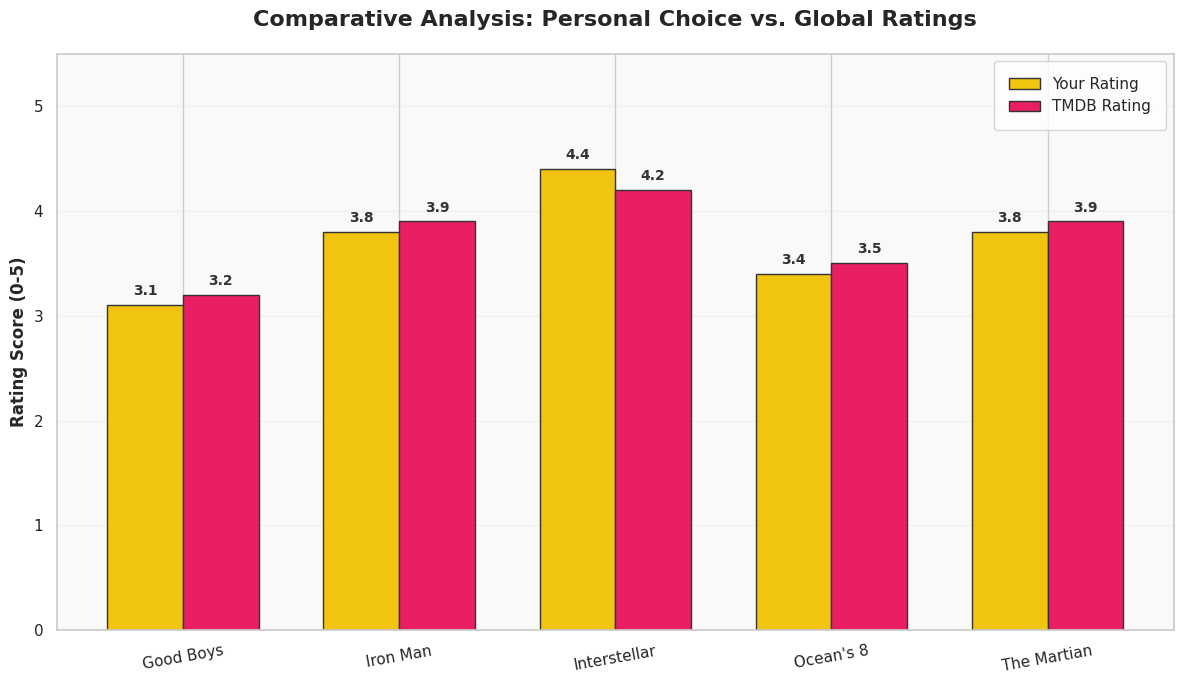

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1.
movies = ['Good Boys', 'Iron Man', 'Interstellar', "Ocean's 8", 'The Martian']
your_ratings = [3.1, 3.8, 4.4, 3.4, 3.8]
tmdb_ratings = [3.2, 3.9, 4.2, 3.5, 3.9]

x = np.arange(len(movies))
width = 0.35

# 2.
fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, your_ratings, width, label='Your Rating',
                color='#F1C40F', edgecolor='#333333', linewidth=1)
rects2 = ax.bar(x + width/2, tmdb_ratings, width, label='TMDB Rating',
                color='#E91E63', edgecolor='#333333', linewidth=1)

# 3.
ax.set_ylabel('Rating Score (0-5)', fontsize=12, fontweight='bold')
ax.set_title('Comparative Analysis: Personal Choice vs. Global Ratings', fontsize=16, pad=20, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(movies, fontsize=11, rotation=10)
ax.set_ylim(0, 5.5)

ax.legend(frameon=True, shadow=False, borderpad=1, fontsize=11)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

autolabel(rects1)
autolabel(rects2)

plt.grid(axis='y', linestyle='-', alpha=0.2, color='#CCCCCC')
plt.gca().set_axisbelow(True)

ax.set_facecolor('#F9F9F9')

plt.tight_layout()
plt.show()

**BONUS POINT 1 : MACHINE LEARNING "PREDICTION" **

In [9]:
# --- BONUS PHASE : MACHINE LEARNING (Regression) ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['popularity', 'rating']]
y = df['success_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("--- 🤖 Machine Learning Interpretation ---")
print(f"Model Accuracy (R2 Score): {r2_score(y_test, y_pred):.2f}")
print(f"Coefficients: Popularity={model.coef_[0]:.2f}, Rating={model.coef_[1]:.2f}")
print("Interpretation: Rating has a stronger impact on the Success Score than raw Popularity.")

--- 🤖 Machine Learning Interpretation ---
Model Accuracy (R2 Score): 0.34
Coefficients: Popularity=0.01, Rating=10.61
Interpretation: Rating has a stronger impact on the Success Score than raw Popularity.


**BONUS POINT 2 : "WORD CLOUD"**

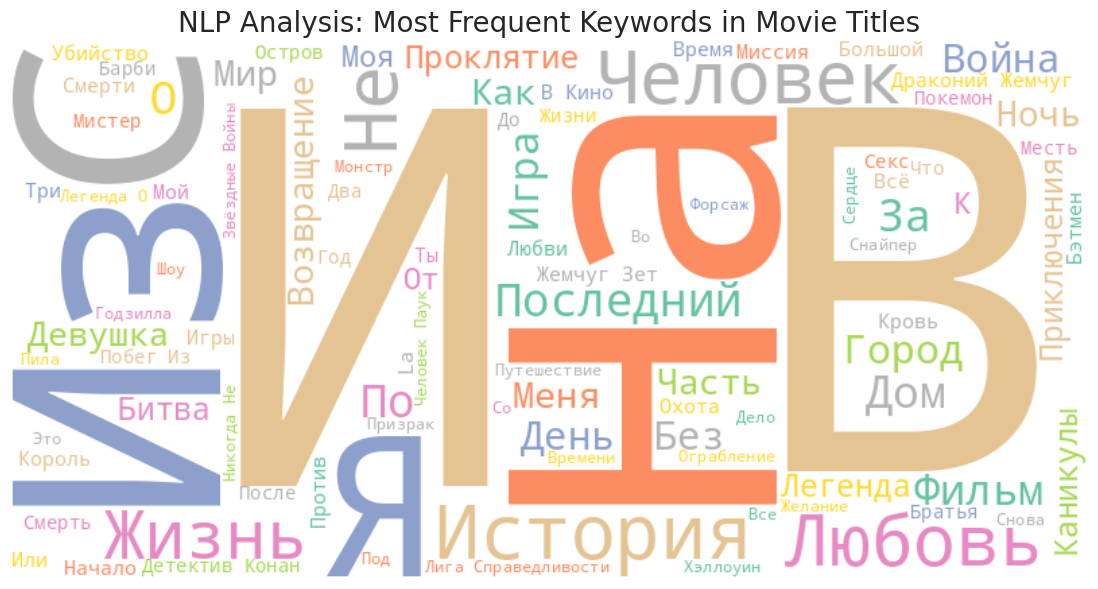

In [10]:
# --- BONUS PHASE : NLP / TEXT ANALYSIS (Word Cloud) ---
from wordcloud import WordCloud

text_data = " ".join(title for title in df.title.astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='Set2', max_words=100).generate(text_data)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("NLP Analysis: Most Frequent Keywords in Movie Titles", fontsize=20)
plt.show()